In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("D:\TVA\Week 2\Social Medai Engagement\Viral_Social_Media_Trends.csv")

In [3]:
df.head()

,Post_ID,Platform,Hashtag,Content_Type,Region,Views,Likes,Shares,Comments,Engagement_Level
0,Post_1,TikTok,#Challenge,Video,UK,4163464,339431,53135,19346,High
1,Post_2,Instagram,#Education,Shorts,India,4155940,215240,65860,27239,Medium
2,Post_3,Twitter,#Challenge,Video,Brazil,3666211,327143,39423,36223,Medium
3,Post_4,YouTube,#Education,Shorts,Australia,917951,127125,11687,36806,Low
4,Post_5,TikTok,#Dance,Post,Brazil,64866,171361,69581,6376,Medium


In [4]:
df.isnull().sum()

Post_ID             0
Platform            0
Hashtag             0
Content_Type        0
Region              0
Views               0
Likes               0
Shares              0
Comments            0
Engagement_Level    0
dtype: int64

In [5]:
# Aggregate views by Platform
platform_views = df.groupby('Platform')['Views'].sum().sort_values(ascending=False)

# Aggregate likes by Content Type
content_likes = df.groupby('Content_Type')['Likes'].mean().sort_values(ascending=False)

In [6]:
df.describe()

,Views,Likes,Shares,Comments
count,5.000000e+03,5000.000000,5000.000000,5000.000000
mean,2.494066e+06,251475.029800,50519.562000,24888.393800
std,1.459490e+06,144349.583384,29066.362671,14284.504319
min,1.266000e+03,490.000000,52.000000,18.000000
25%,1.186207e+06,126892.250000,25029.000000,12305.250000
50%,2.497373e+06,249443.000000,50839.500000,25004.000000
75%,3.759781e+06,373970.750000,75774.250000,37072.750000
max,4.999430e+06,499922.000000,99978.000000,49993.000000


In [7]:
df.shape

(5000, 10)

In [9]:
print(content_likes)

Content_Type
Reel           255011.068966
Video          254768.923913
Post           252784.174678
Tweet          249384.470096
Live Stream    248811.616374
Shorts         247926.202033
Name: Likes, dtype: float64


In [8]:
print(platform_views)

Platform
YouTube      3370438480
TikTok       3168919406
Twitter      3017229522
Instagram    2913744812
Name: Views, dtype: int64


In [14]:
df['Total_Engagement'] = df['Likes'] + df['Shares'] + df['Comments']
df['Engagement_Rate'] = (df['Total_Engagement'] / df['Views']) * 100

C:\Users\visha\AppData\Local\Temp\ipykernel_22104\668538764.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=platform_views, x='Platform', y='Views', palette='viridis')


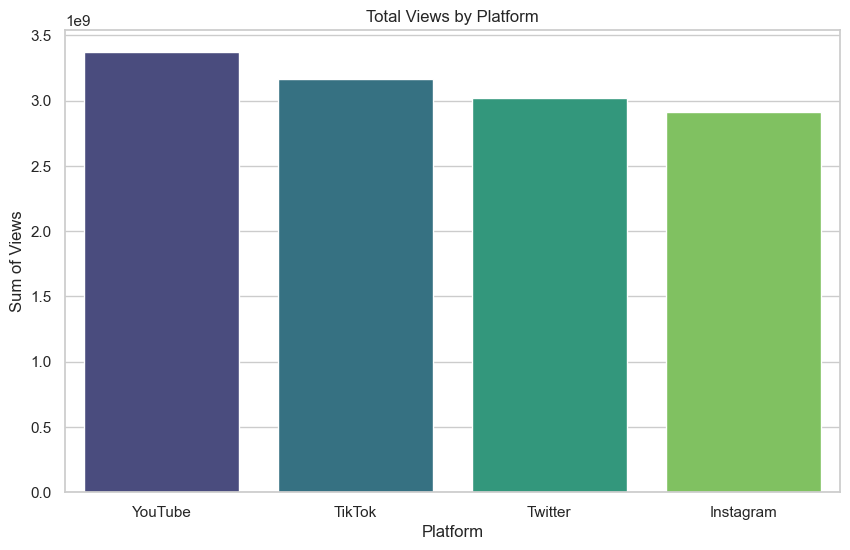

In [15]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
platform_views = df.groupby('Platform')['Views'].sum().sort_values(ascending=False).reset_index()
sns.barplot(data=platform_views, x='Platform', y='Views', palette='viridis')
plt.title('Total Views by Platform')
plt.ylabel('Sum of Views')
plt.show()

C:\Users\visha\AppData\Local\Temp\ipykernel_22104\1098714128.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=content_eff, x='Content_Type', y='Engagement_Rate', palette='magma')


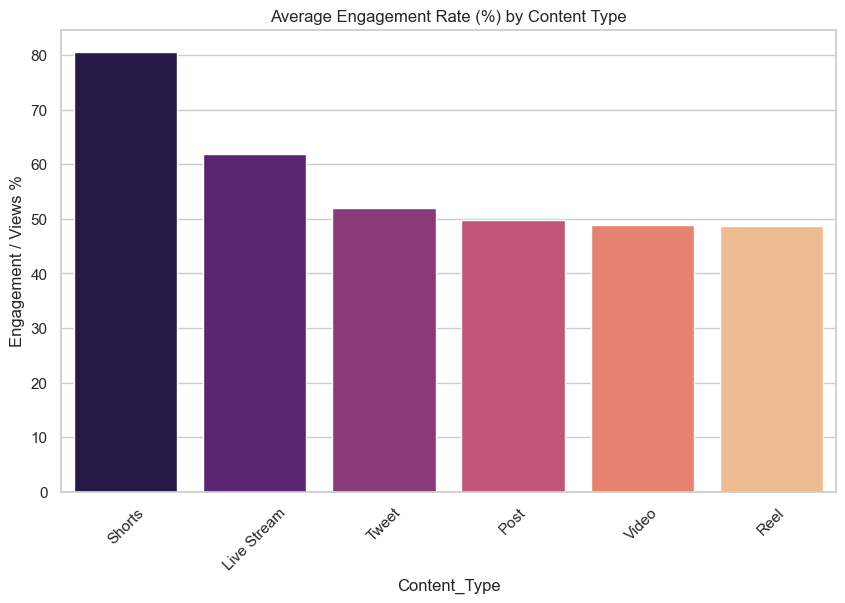

In [16]:
plt.figure(figsize=(10, 6))
content_eff = df.groupby('Content_Type')['Engagement_Rate'].mean().sort_values(ascending=False).reset_index()
sns.barplot(data=content_eff, x='Content_Type', y='Engagement_Rate', palette='magma')
plt.title('Average Engagement Rate (%) by Content Type')
plt.ylabel('Engagement / Views %')
plt.xticks(rotation=45)
plt.show()